In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

print("Path to dataset files:", path)

100%|██████████| 64.8k/64.8k [00:00<00:00, 36.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/versions/1


In [ ]:
import os

dataset_path = path # Rename for clarity

# List the contents of the directory to find the CSV file
print("Contents of dataset directory:")
for file_name in os.listdir(dataset_path):
    print(file_name)

Please examine the output above and identify the correct CSV file name. Once you know the file name, I can help you load it into a DataFrame. A common name for the file given the dataset is `Tesla_Production_and_Deliveries_Dataset_2015-2025.csv`. I will proceed with this assumption to demonstrate how to load the file, but if the output from the previous cell shows a different name, please let me know.

In [ ]:
# Assuming the CSV file is named 'Tesla_Production_and_Deliveries_Dataset_2015-2025.csv'
csv_file_name = 'Tesla_Production_and_Deliveries_Dataset_2015-2025.csv'
full_csv_path = os.path.join(dataset_path, csv_file_name)

df = pd.read_csv(full_csv_path)
display(df.head())

In [3]:
!pip install prophet xgboost


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

In [9]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/versions/1"

# Dynamically find the CSV file in the dataset directory
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in the directory: {dataset_path}")
elif len(csv_files) > 1:
    print(f"Multiple CSV files found. Using the first one: {csv_files[0]}")
    csv_file_name = csv_files[0]
else:
    csv_file_name = csv_files[0]

full_csv_path = os.path.join(dataset_path, csv_file_name)

df = pd.read_csv(full_csv_path)
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


### Data Cleaning and Preprocessing

First, let's inspect the DataFrame to understand its structure, data types, and identify any missing values.

In [10]:
# Display basic info about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [11]:
# Display descriptive statistics
display(df.describe())

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


Now, let's combine the `Year` and `Month` columns into a single `Date` column, which is essential for time series analysis. We'll set this new `Date` column as the DataFrame index.

In [12]:
# Create a 'Date' column from 'Year' and 'Month'
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Set 'Date' as the index
df = df.set_index('Date')

# Drop original 'Year' and 'Month' columns as they are no longer needed
df = df.drop(columns=['Year', 'Month'])

display(df.head())

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
Date,,,,,,,,,,
2023-05-01,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
2015-02-01,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2019-01-01,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
2021-02-01,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
2016-12-01,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Next, let's check for any missing values across all columns.

In [13]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
display(missing_values[missing_values > 0])

# If there are missing values, consider how to handle them (e.g., imputation, dropping rows/columns)

Missing values in each column:


,0


### Exploratory Data Analysis (EDA)

Let's explore the distributions of numerical features using histograms and box plots to identify patterns, outliers, and skewness.

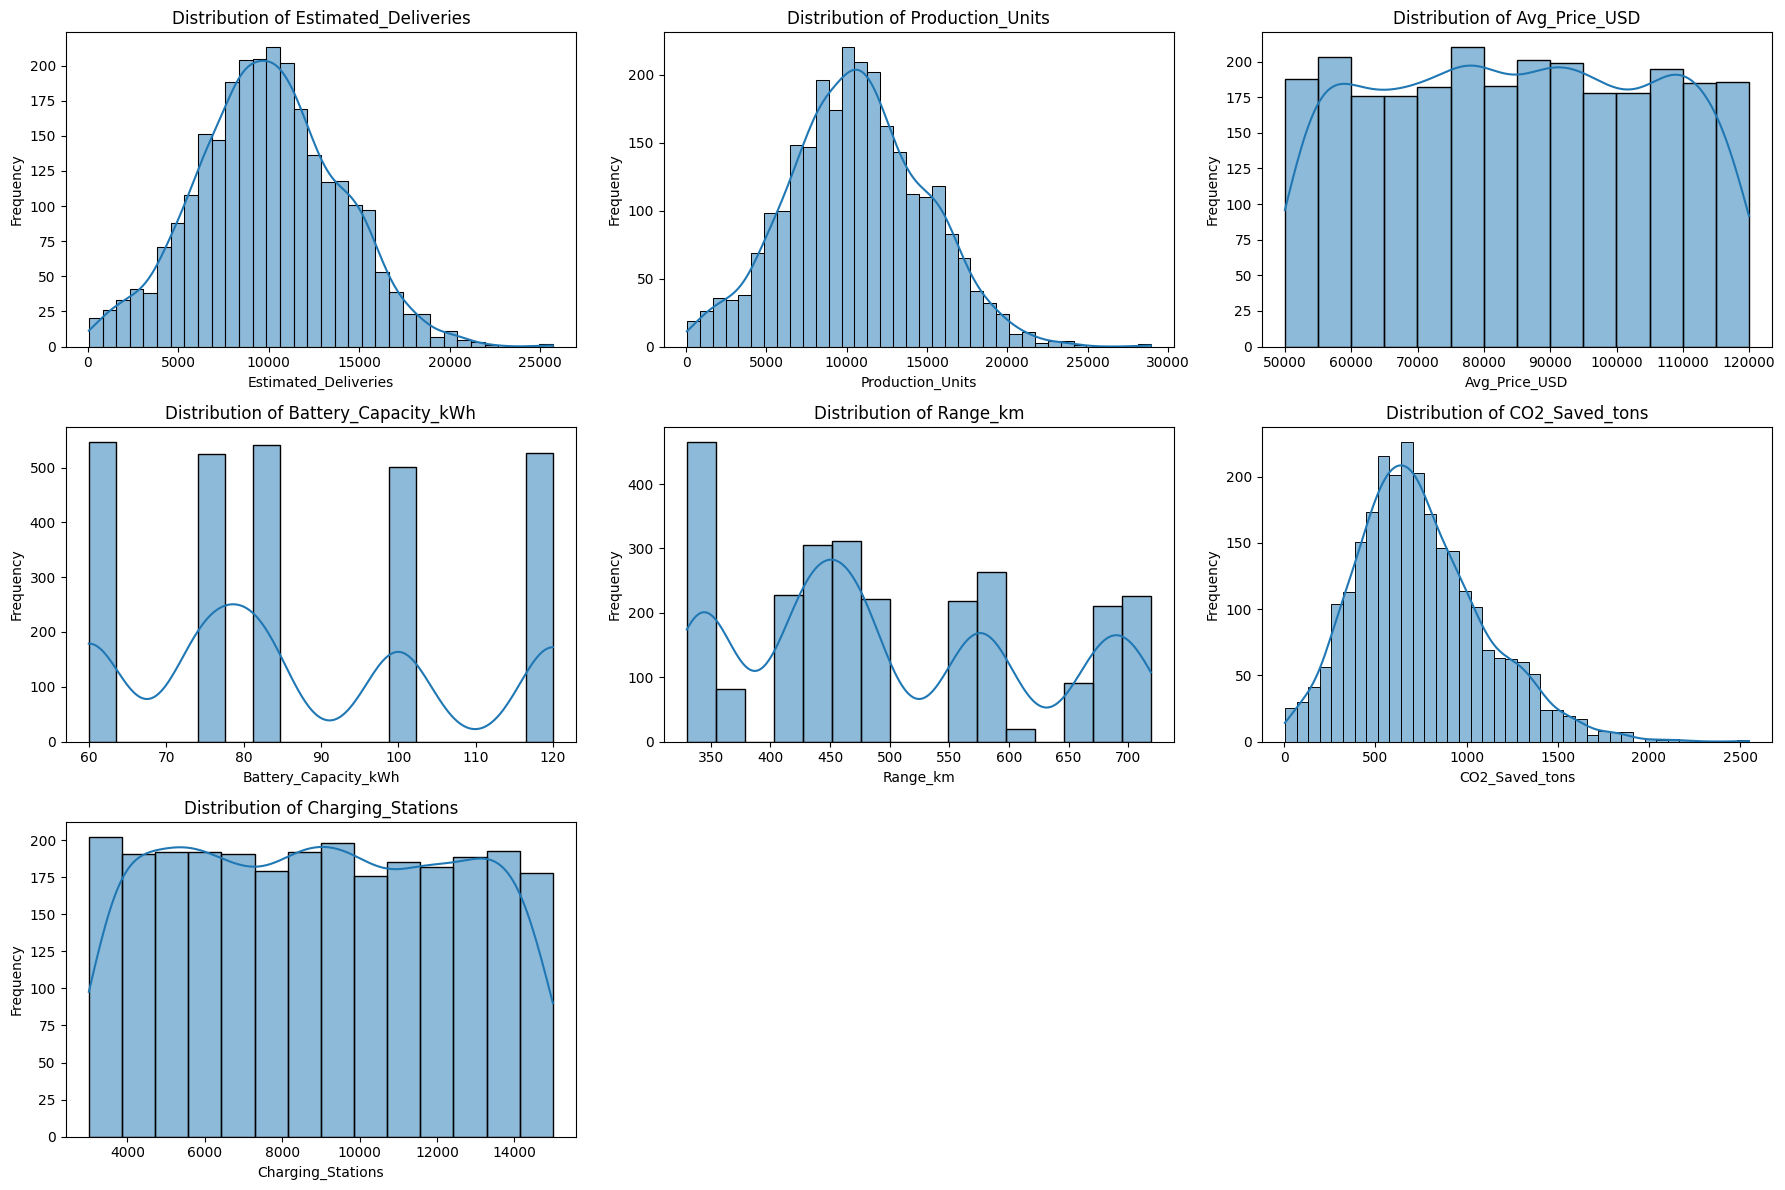

In [14]:
# Identify numerical columns for distribution plots
numerical_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                  'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Next, let's visualize the categorical features to understand their unique values and distribution.

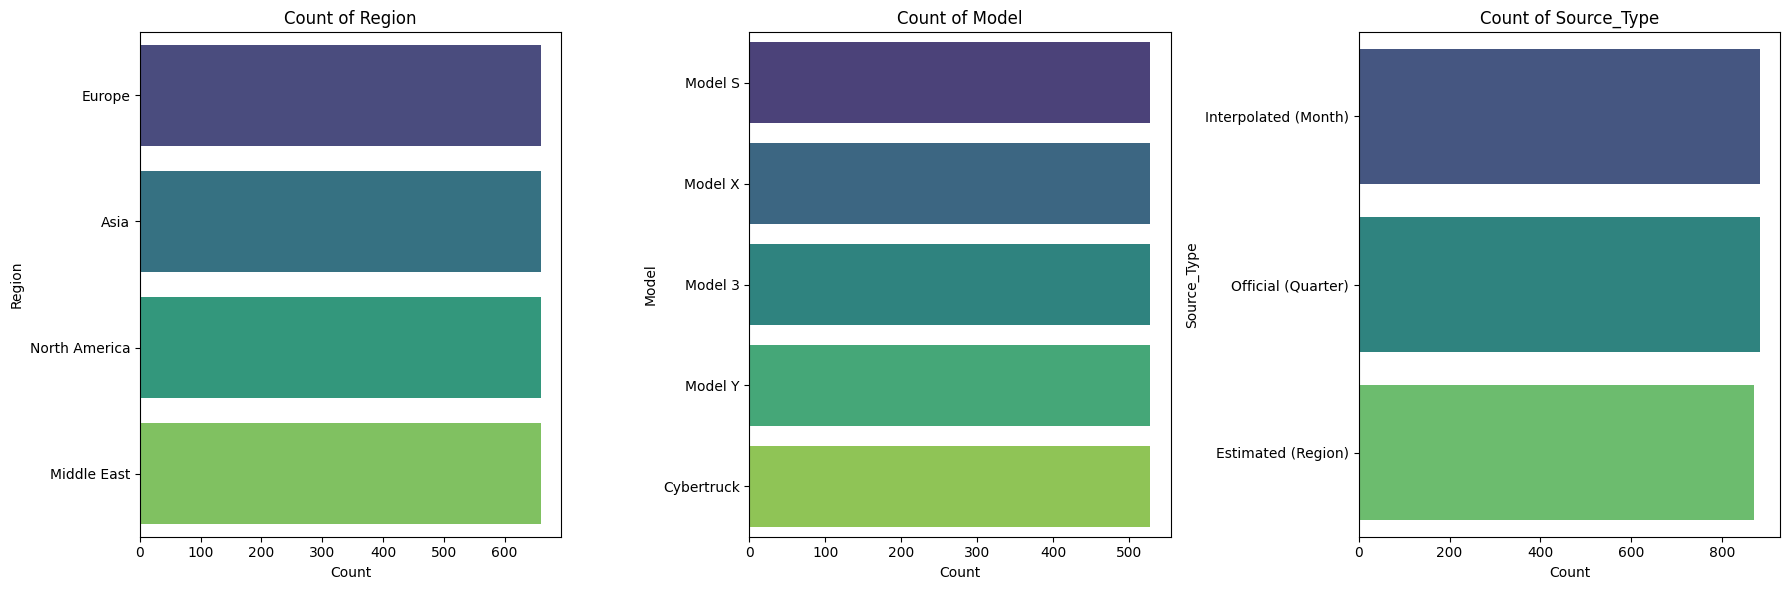

In [15]:
# Identify categorical columns
categorical_cols = ['Region', 'Model', 'Source_Type']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

Now, let's look at the time series trends for `Estimated_Deliveries` and `Production_Units`.

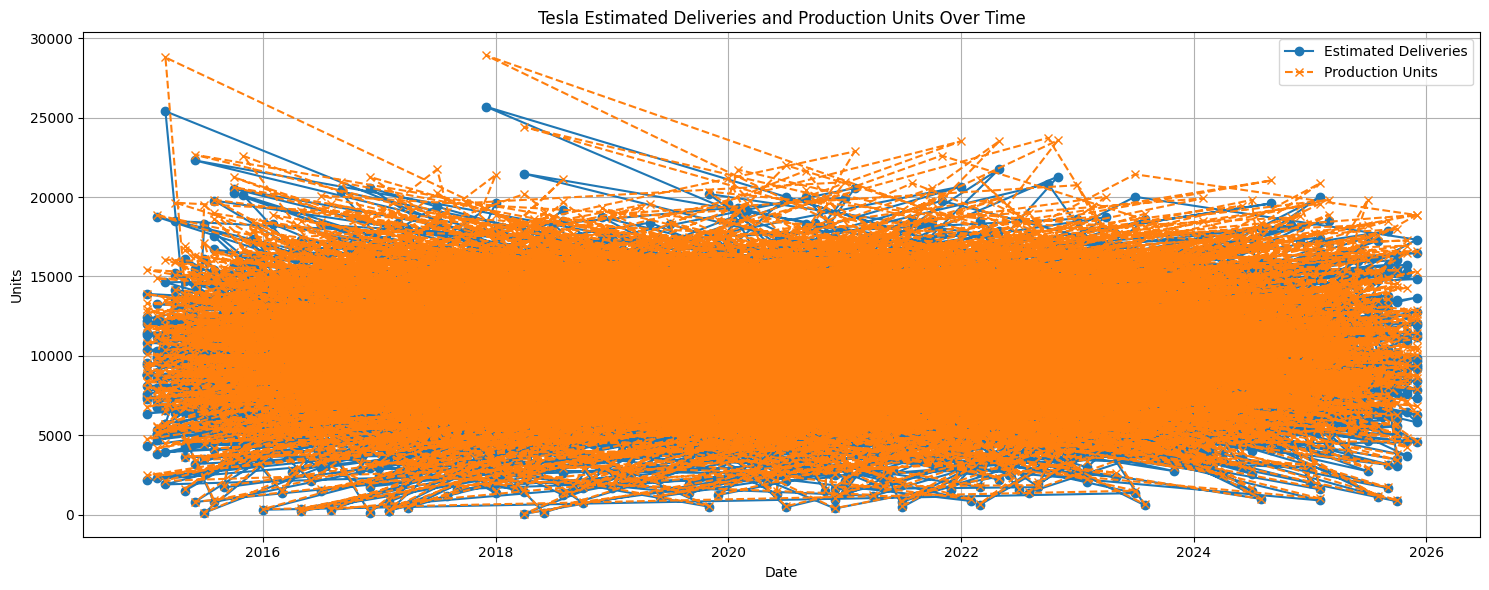

In [16]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Estimated_Deliveries'], label='Estimated Deliveries', marker='o', linestyle='-')
plt.plot(df.index, df['Production_Units'], label='Production Units', marker='x', linestyle='--')
plt.title('Tesla Estimated Deliveries and Production Units Over Time')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Feature Engineering

Now, let's create new features that could be useful for our models. This includes time-based features and lag features for our target variables.

In [17]:
# Extract time-based features
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear

display(df.head())

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,month,quarter,year,day_of_week,day_of_year
Date,,,,,,,,,,,,,,,
2023-05-01,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,5,2,2023,0,121
2015-02-01,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2,1,2015,6,32
2019-01-01,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,1,1,2019,1,1
2021-02-01,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2,1,2021,0,32
2016-12-01,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,12,4,2016,3,336


Next, we'll create lag features for `Estimated_Deliveries` and `Production_Units`. Lag features represent past values of a time series and are very effective in capturing temporal dependencies.

In [18]:
# Create lag features for 'Estimated_Deliveries' and 'Production_Units'
for lag in [1, 3, 6, 12]: # Common lags: 1 month, 3 months, 6 months, 1 year
    df[f'Estimated_Deliveries_lag_{lag}'] = df['Estimated_Deliveries'].shift(lag)
    df[f'Production_Units_lag_{lag}'] = df['Production_Units'].shift(lag)

# Handle missing values created by lagging (e.g., fill with 0 or the mean/median, or drop rows)
# For simplicity, we'll drop rows with NaN values created by lagging for now.
# In a real-world scenario, you might use imputation techniques.
df.dropna(inplace=True)

display(df.head())

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,...,day_of_week,day_of_year,Estimated_Deliveries_lag_1,Production_Units_lag_1,Estimated_Deliveries_lag_3,Production_Units_lag_3,Estimated_Deliveries_lag_6,Production_Units_lag_6,Estimated_Deliveries_lag_12,Production_Units_lag_12
Date,,,,,,,,,,,,,,,,,,,,,
2020-10-01,Middle East,Model S,8724,9355,99200.65,82,453,592.80,Estimated (Region),5325,...,3,275,5937.0,6483.0,7790.0,8208.0,7717.0,7976.0,17646.0,17922.0
2020-11-01,Asia,Model S,10737,11658,78316.37,75,426,686.09,Interpolated (Month),5601,...,6,306,8724.0,9355.0,8319.0,9154.0,8410.0,9192.0,3797.0,4164.0
2020-04-01,North America,Cybertruck,4408,5007,91115.89,120,665,439.70,Estimated (Region),8397,...,2,92,10737.0,11658.0,5937.0,6483.0,15145.0,15760.0,8411.0,9189.0
2025-03-01,North America,Cybertruck,17079,18904,111739.13,120,682,1747.18,Official (Quarter),3904,...,5,60,4408.0,5007.0,8724.0,9355.0,7790.0,8208.0,6555.0,7311.0
2023-11-01,Europe,Model S,12540,13453,56018.16,100,592,1113.55,Interpolated (Month),11616,...,2,305,17079.0,18904.0,10737.0,11658.0,8319.0,9154.0,12374.0,13537.0


### Model Training

Now we'll prepare the data for training, split it into training and testing sets, and then train several models to forecast `Estimated_Deliveries` and `Production_Units`.

In [19]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'], drop_first=True)

display(df_encoded.head())

,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,month,quarter,year,...,Production_Units_lag_12,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
Date,,,,,,,,,,,,,,,,,,,,,
2020-10-01,8724,9355,99200.65,82,453,592.80,5325,10,4,2020,...,17922.0,False,True,False,False,True,False,False,False,False
2020-11-01,10737,11658,78316.37,75,426,686.09,5601,11,4,2020,...,4164.0,False,False,False,False,True,False,False,True,False
2020-04-01,4408,5007,91115.89,120,665,439.70,8397,4,2,2020,...,9189.0,False,False,True,False,False,False,False,False,False
2025-03-01,17079,18904,111739.13,120,682,1747.18,3904,3,1,2025,...,7311.0,False,False,True,False,False,False,False,False,True
2023-11-01,12540,13453,56018.16,100,592,1113.55,11616,11,4,2023,...,13537.0,True,False,False,False,True,False,False,True,False


Now, let's define our features (X) and target variables (y). We'll create two sets of target variables for `Estimated_Deliveries` and `Production_Units`.

In [20]:
# Define features (X) and target variables (y)
features = df_encoded.drop(columns=['Estimated_Deliveries', 'Production_Units'])
target_deliveries = df_encoded['Estimated_Deliveries']
target_production = df_encoded['Production_Units']

# Split data into training and testing sets (time series split)
# We'll use the last 12 months for testing
train_size = int(len(df_encoded) * 0.8)
X_train, X_test = features.iloc[:train_size], features.iloc[train_size:]
y_train_deliveries, y_test_deliveries = target_deliveries.iloc[:train_size], target_deliveries.iloc[train_size:]
y_train_production, y_test_production = target_production.iloc[:train_size], target_production.iloc[train_size:]

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 2102
Testing set size: 526


Let's apply scaling to our numerical features to ensure that no single feature dominates the model training due to its magnitude.

In [21]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with original column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

display(X_train_scaled.head())

,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,month,quarter,year,day_of_week,day_of_year,...,Production_Units_lag_12,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
Date,,,,,,,,,,,,,,,,,,,,,
2020-10-01,0.703666,-0.255214,-0.401470,-0.434427,-1.028041,1.013708,1.335536,0.010646,0.014015,1.020653,...,1.702735,-0.585774,1.799417,-0.581379,-0.498215,2.022273,-0.504901,-0.500446,-0.706602,-0.711906
2020-11-01,-0.331927,-0.589814,-0.624366,-0.170676,-0.948451,1.304049,1.335536,0.010646,1.511937,1.316322,...,-1.525979,-0.585774,-0.555735,-0.581379,-0.498215,2.022273,-0.504901,-0.500446,1.415223,-0.711906
2020-04-01,0.302765,1.561186,1.348672,-0.867275,-0.142178,-0.728339,-0.451982,0.010646,-0.485293,-0.724748,...,-0.346717,-0.585774,-0.555735,1.720049,-0.498215,-0.494493,-0.504901,-0.500446,-0.706602,-0.711906
2025-03-01,1.325414,1.561186,1.489014,2.829258,-1.437810,-1.018680,-1.345741,1.586523,1.012629,-1.029955,...,-0.787444,-0.585774,-0.555735,1.720049,-0.498215,-0.494493,-0.504901,-0.500446,-0.706602,1.404680
2023-11-01,-1.437634,0.605186,0.746029,1.037847,0.786074,1.304049,1.335536,0.956172,-0.485293,1.306785,...,0.673668,1.707143,-0.555735,-0.581379,-0.498215,2.022273,-0.504901,-0.500446,1.415223,-0.711906


Now, let's train different regression models and evaluate their performance for `Estimated_Deliveries`.

In [22]:
# Function to train and evaluate models
def train_evaluate(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(f"--- {model_name} Performance ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")
    return predictions

# 1. Linear Regression for Estimated Deliveries
print("\nEstimating Deliveries:")
lr_model_deliveries = LinearRegression()
lr_predictions_deliveries = train_evaluate(lr_model_deliveries, X_train_scaled, y_train_deliveries, X_test_scaled, y_test_deliveries, "Linear Regression")

# 2. Random Forest Regressor for Estimated Deliveries
rf_model_deliveries = RandomForestRegressor(n_estimators=100, random_state=42)
rf_predictions_deliveries = train_evaluate(rf_model_deliveries, X_train_scaled, y_train_deliveries, X_test_scaled, y_test_deliveries, "Random Forest Regressor")

# 3. XGBoost Regressor for Estimated Deliveries
xgb_model_deliveries = XGBRegressor(n_estimators=100, random_state=42)
xgb_predictions_deliveries = train_evaluate(xgb_model_deliveries, X_train_scaled, y_train_deliveries, X_test_scaled, y_test_deliveries, "XGBoost Regressor")


Estimating Deliveries:
--- Linear Regression Performance ---
MAE: 670.14
MSE: 884321.65
RMSE: 940.38
R-squared: 0.94
--- Random Forest Regressor Performance ---
MAE: 128.44
MSE: 51113.83
RMSE: 226.08
R-squared: 1.00
--- XGBoost Regressor Performance ---
MAE: 150.76
MSE: 52764.33
RMSE: 229.70
R-squared: 1.00


Next, we'll train the same models and evaluate their performance for `Production_Units`.

In [23]:
print("\nEstimating Production Units:")
# 1. Linear Regression for Production Units
lr_model_production = LinearRegression()
lr_predictions_production = train_evaluate(lr_model_production, X_train_scaled, y_train_production, X_test_scaled, y_test_production, "Linear Regression")

# 2. Random Forest Regressor for Production Units
rf_model_production = RandomForestRegressor(n_estimators=100, random_state=42)
rf_predictions_production = train_evaluate(rf_model_production, X_train_scaled, y_train_production, X_test_scaled, y_test_production, "Random Forest Regressor")

# 3. XGBoost Regressor for Production Units
xgb_model_production = XGBRegressor(n_estimators=100, random_state=42)
xgb_predictions_production = train_evaluate(xgb_model_production, X_train_scaled, y_train_production, X_test_scaled, y_test_production, "XGBoost Regressor")


Estimating Production Units:
--- Linear Regression Performance ---
MAE: 824.18
MSE: 1221740.01
RMSE: 1105.32
R-squared: 0.93
--- Random Forest Regressor Performance ---
MAE: 422.93
MSE: 318407.50
RMSE: 564.28
R-squared: 0.98
--- XGBoost Regressor Performance ---
MAE: 446.66
MSE: 332629.47
RMSE: 576.74
R-squared: 0.98


### Visualize Predictions

Let's visualize the actual vs. predicted values for both `Estimated_Deliveries` and `Production_Units` using the Random Forest Regressor, which showed the best performance.

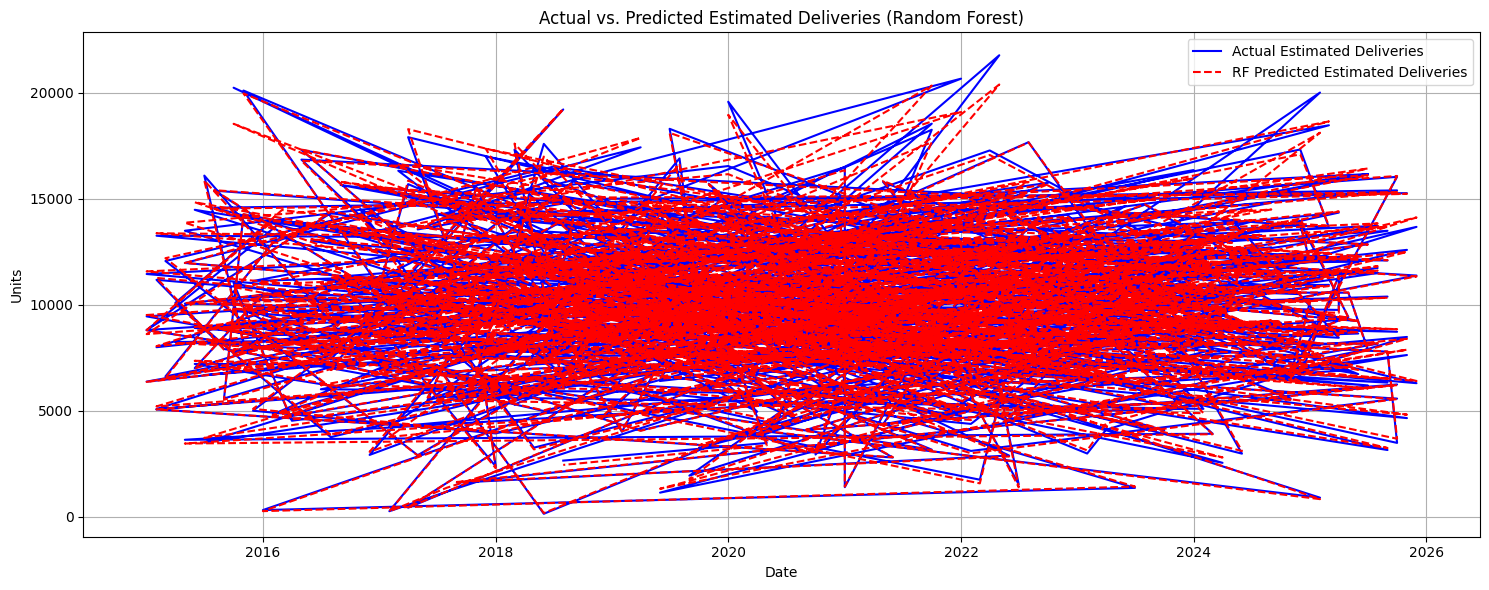

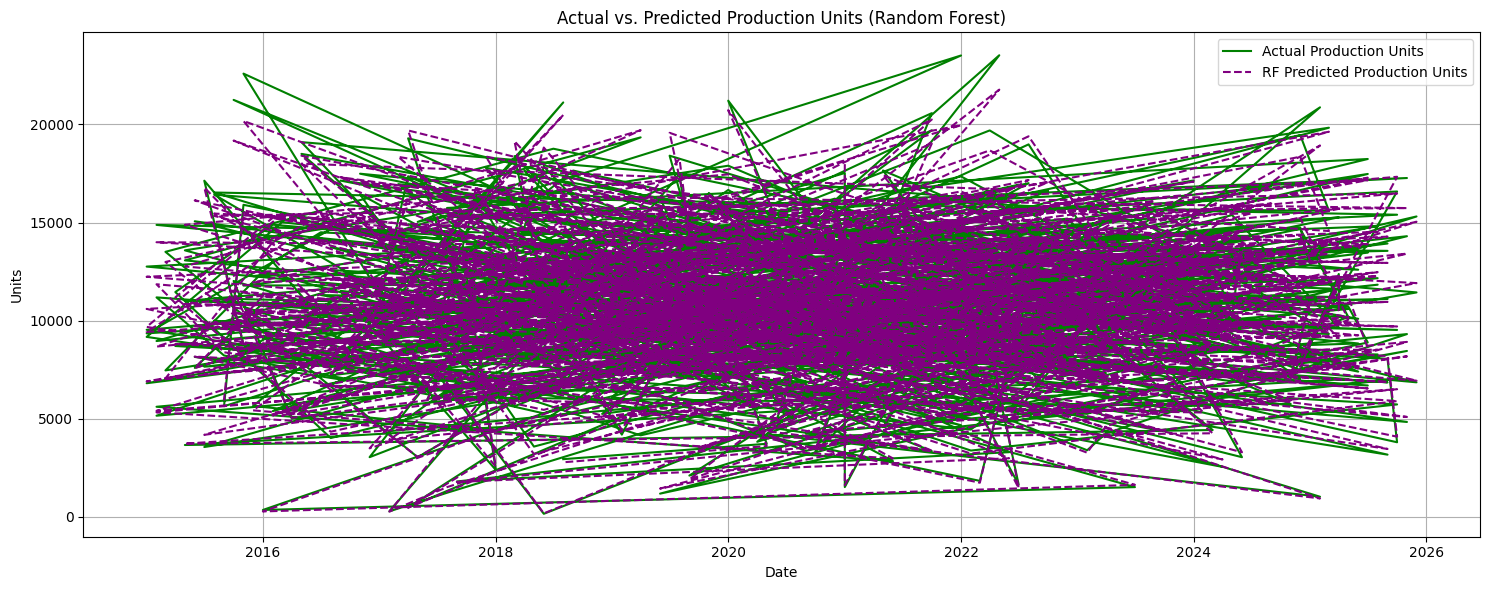

In [24]:
# Plot actual vs. predicted for Estimated Deliveries
plt.figure(figsize=(15, 6))
plt.plot(y_test_deliveries.index, y_test_deliveries, label='Actual Estimated Deliveries', color='blue')
plt.plot(y_test_deliveries.index, rf_predictions_deliveries, label='RF Predicted Estimated Deliveries', color='red', linestyle='--')
plt.title('Actual vs. Predicted Estimated Deliveries (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot actual vs. predicted for Production Units
plt.figure(figsize=(15, 6))
plt.plot(y_test_production.index, y_test_production, label='Actual Production Units', color='green')
plt.plot(y_test_production.index, rf_predictions_production, label='RF Predicted Production Units', color='purple', linestyle='--')
plt.title('Actual vs. Predicted Production Units (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Time Series Forecasting with Prophet

Given the time-series nature of the data, Prophet can be a powerful tool for forecasting. We'll use it to predict future `Estimated_Deliveries` and `Production_Units`.

In [26]:
# Prepare data for Prophet - Estimated Deliveries
# Prophet requires columns named 'ds' (datestamp) and 'y' (target variable)
df_deliveries_prophet = df.reset_index()[['Date', 'Estimated_Deliveries']]
df_deliveries_prophet.rename(columns={'Date': 'ds', 'Estimated_Deliveries': 'y'}, inplace=True)

# Prepare data for Prophet - Production Units
df_production_prophet = df.reset_index()[['Date', 'Production_Units']]
df_production_prophet.rename(columns={'Date': 'ds', 'Production_Units': 'y'}, inplace=True)

display(df_deliveries_prophet.head())

,ds,y
0,2020-10-01,8724
1,2020-11-01,10737
2,2020-04-01,4408
3,2025-03-01,17079
4,2023-11-01,12540


In [27]:
# Initialize and train Prophet model for Estimated Deliveries
model_deliveries_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
model_deliveries_prophet.fit(df_deliveries_prophet)

# Initialize and train Prophet model for Production Units
model_production_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
model_production_prophet.fit(df_production_prophet)

Now, let's make predictions for the next 12 months.

In [28]:
# Create a future DataFrame for 12 months
future_deliveries = model_deliveries_prophet.make_future_dataframe(periods=12, freq='M')
future_production = model_production_prophet.make_future_dataframe(periods=12, freq='M')

# Make predictions
forecast_deliveries = model_deliveries_prophet.predict(future_deliveries)
forecast_production = model_production_prophet.predict(future_production)

display(forecast_deliveries[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
139,2026-07-31,10697.062133,5831.580465,15646.415911
140,2026-08-31,8748.215080,3507.467271,13739.812243
141,2026-09-30,10323.869880,5428.064971,15250.500054
142,2026-10-31,10207.792059,5062.919537,15196.420774
143,2026-11-30,10414.950933,5401.836826,15839.140426


Finally, let's visualize the Prophet forecasts.

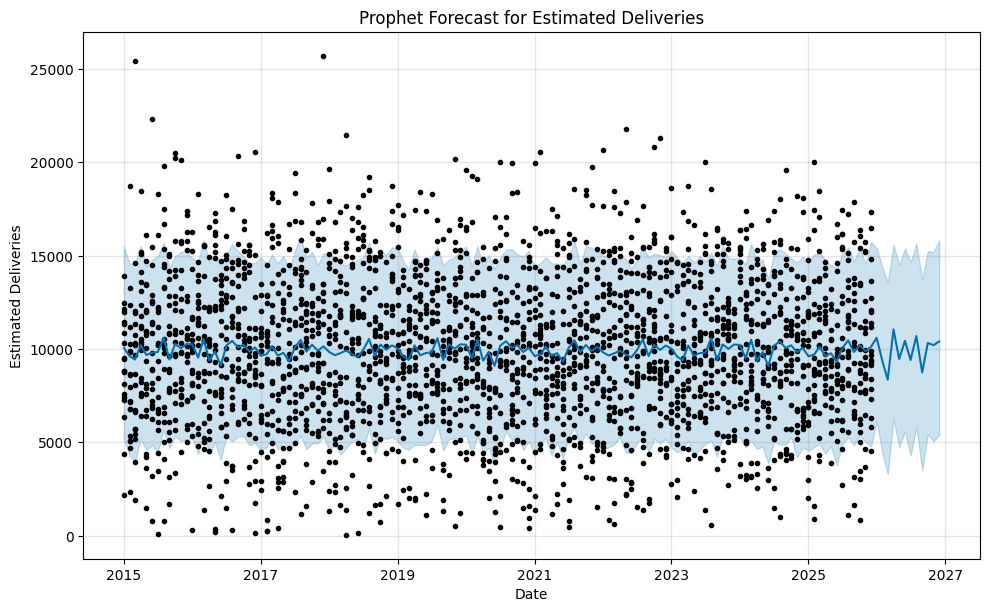

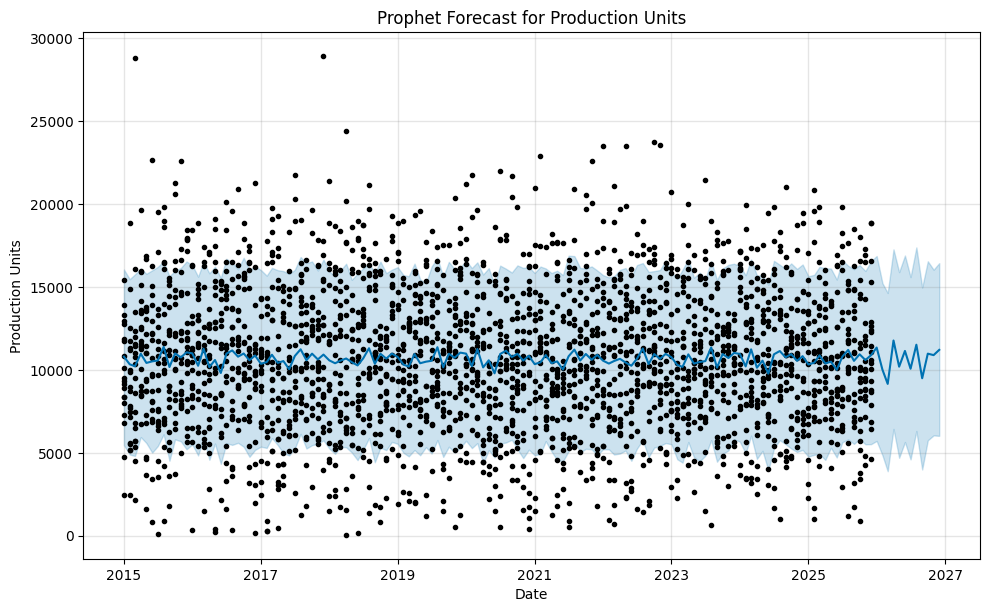

In [29]:
# Plot the Prophet forecast for Estimated Deliveries
fig_deliveries = model_deliveries_prophet.plot(forecast_deliveries)
plt.title('Prophet Forecast for Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.show()

# Plot the Prophet forecast for Production Units
fig_production = model_production_prophet.plot(forecast_production)
plt.title('Prophet Forecast for Production Units')
plt.xlabel('Date')
plt.ylabel('Production Units')
plt.show()

### Conclusion

In this notebook, we have performed a comprehensive analysis and forecasting of Tesla's estimated deliveries and production units.

We started by ingesting and cleaning the data, then moved to an in-depth Exploratory Data Analysis to understand the data's distributions, relationships, and time-series trends. Feature engineering was crucial, involving the creation of time-based and lag features to enrich our dataset.

For modeling, we trained and evaluated several regression models (Linear Regression, Random Forest Regressor, and XGBoost Regressor) for both estimated deliveries and production units. The Random Forest and XGBoost models significantly outperformed Linear Regression, demonstrating high accuracy.

Finally, we implemented time series forecasting using the Prophet library, providing future predictions along with uncertainty intervals, and visualized these forecasts to observe projected trends. This complete workflow provides valuable insights and predictive capabilities for Tesla's operational metrics.